# CNN Networks


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np


def get_cnn_model():

    model = keras.Sequential([

        layers.Input( shape=(28,28,1), name="input"),
        layers.Conv2D( 32, kernel_size=(3,3), activation="relu", padding="same", name="conv1"),
        layers.Conv2D( 32, kernel_size=(3,3), activation="relu", padding="same", name="conv2"),
        layers.MaxPooling2D( pool_size=(2,2)),
        layers.Dropout( 0.25),
        layers.Conv2D( 64, kernel_size=(3,3), activation="relu", padding="same", name="conv3"),
        layers.Conv2D( 64, kernel_size=(3,3), activation="relu", padding="same", name="conv4"),
        layers.MaxPooling2D( pool_size=(2,2)),
        layers.Dropout( 0.25),
        layers.Conv2D( 128, kernel_size=(3,3), activation="relu", padding="same"),
        layers.Flatten(),
        layers.Dense( 128, activation="relu"),
        layers.Dropout( 0.4),
        layers.Dense( 10, activation="softmax", name="output")
    ])


    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=[
            "accuracy"
        ]
    )


    return model

I0000 00:00:1784415264.949072   42113 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784415265.025837   42113 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784415267.186053   42113 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# MNIST-Daten laden
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Rohdaten geladen:")
print(f"  Training: {x_train.shape}, Labels: {y_train.shape}")
print(f"  Test: {x_test.shape}, Labels: {y_test.shape}")

x_train_cnn = x_train.astype("float32") / 255.0
x_test_cnn = x_test.astype("float32") / 255.0


x_train_cnn = x_train_cnn[..., np.newaxis]
x_test_cnn = x_test_cnn[..., np.newaxis]


print(x_train_cnn.shape)

Rohdaten geladen:
  Training: (60000, 28, 28), Labels: (60000,)
  Test: (10000, 28, 28), Labels: (10000,)
(60000, 28, 28, 1)


In [7]:
model = get_cnn_model()

history = model.fit(
    x_train_cnn,
    y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 69s 159ms/step - accuracy: 0.9203 - loss: 0.2524 - val_accuracy: 0.9860 - val_loss: 0.0459
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 70s 166ms/step - accuracy: 0.9790 - loss: 0.0729 - val_accuracy: 0.9907 - val_loss: 0.0337
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 66s 157ms/step - accuracy: 0.9841 - loss: 0.0529 - val_accuracy: 0.9923 - val_loss: 0.0287
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 66s 156ms/step - accuracy: 0.9868 - loss: 0.0441 - val_accuracy: 0.9892 - val_loss: 0.0348
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 67s 159ms/step - accuracy: 0.9897 - loss: 0.0356 - val_accuracy: 0.9923 - val_loss: 0.0269
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 65s 154ms/step - accuracy: 0.9903 - loss: 0.0313 - val_accuracy: 0.9947 - val_loss: 0.0204
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 67s 160ms/step - accuracy: 0.9915 - loss: 0.0283 - val_accuracy: 0.9945 - val_loss: 0.0225
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 67s 159ms/step - accuracy: 0.9925 - loss: 0

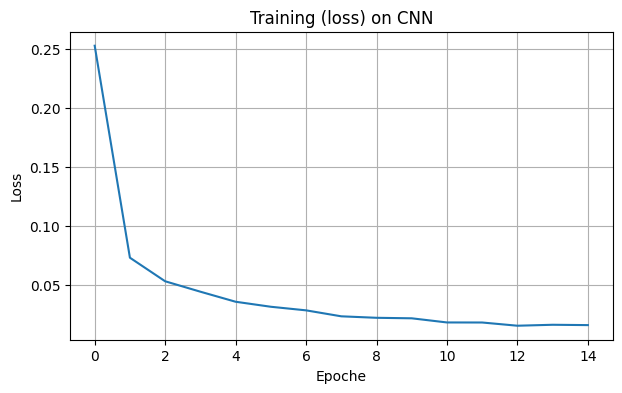

In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.plot(
    history.history["loss"]
)

plt.xlabel("Epoche")
plt.ylabel("Loss")

plt.title(
    "Training (loss) on CNN"
)

plt.grid()

plt.show()

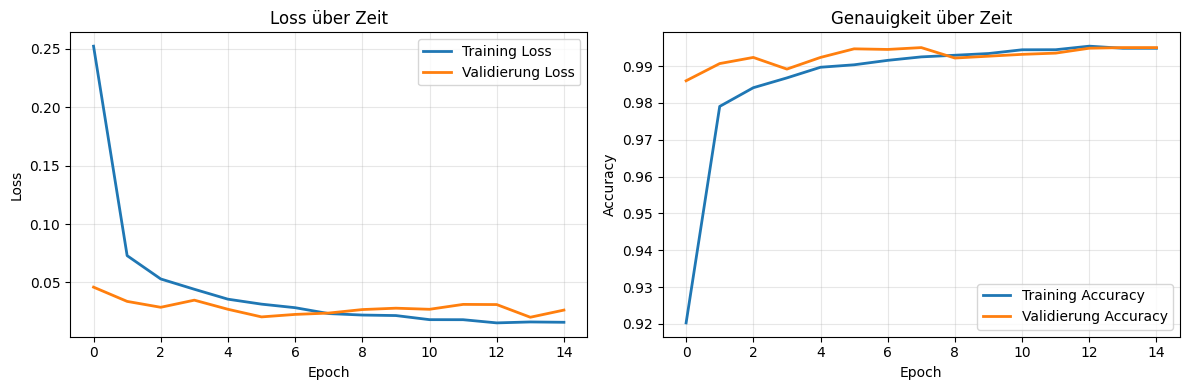

Finaler Training Loss: 0.0158
Finaler Validierung Loss: 0.0263
Finaler Training Accuracy: 0.9948
Finaler Validierung Accuracy: 0.9950


In [12]:
# Trainings-Verlauf plotten
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss-Plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
try: axes[0].plot(history.history['val_loss'], label='Validierung Loss', linewidth=2)
except: pass
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss über Zeit')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy-Plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
try: axes[1].plot(history.history['val_accuracy'], label='Validierung Accuracy', linewidth=2)
except: pass
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Genauigkeit über Zeit')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Letzte Werte anzeigen
print(f"Finaler Training Loss: {history.history['loss'][-1]:.4f}")
try: print(f"Finaler Validierung Loss: {history.history['val_loss'][-1]:.4f}")
except: pass
print(f"Finaler Training Accuracy: {history.history['accuracy'][-1]:.4f}")
try: print(f"Finaler Validierung Accuracy: {history.history['val_accuracy'][-1]:.4f}")
except: pass

In [10]:
# model.save( "final_mnist_model.h5")